In [193]:
import sys

sys.path.append("..")

import pandas as pd 
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split , RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression , Lasso , Ridge , ElasticNet
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor



from src.data.cleaning import (
    clean_dataset
)

from src.features.engineering import (
    create_features
)

In [194]:
df.corr(numeric_only=True).style.background_gradient(cmap="coolwarm")


,year,selling_price,km_driven,mileage,seats,engine_cc,max_power_bhp,torque_nm,torque_rpm_min,torque_rpm_max,age
year,1.000000,0.433076,-0.377003,0.366694,0.023632,-0.019074,0.159688,0.049021,-0.018774,0.069321,-1.000000
selling_price,0.433076,1.000000,-0.165620,-0.108344,0.158111,0.442857,0.691536,0.443228,-0.260272,-0.092892,-0.433076
km_driven,-0.377003,-0.165620,1.000000,-0.196494,0.207957,0.253339,0.041777,0.122158,-0.240163,-0.234358,0.377003
mileage,0.366694,-0.108344,-0.196494,1.000000,-0.459624,-0.578483,-0.378609,-0.229424,-0.032774,-0.193556,-0.366694
seats,0.023632,0.158111,0.207957,-0.459624,1.000000,0.657798,0.259028,0.309053,-0.364804,-0.227959,-0.023632
engine_cc,-0.019074,0.442857,0.253339,-0.578483,0.657798,1.000000,0.683506,0.575978,-0.486663,-0.266963,0.019074
max_power_bhp,0.159688,0.691536,0.041777,-0.378609,0.259028,0.683506,1.000000,0.630170,-0.268219,-0.026144,-0.159688
torque_nm,0.049021,0.443228,0.122158,-0.229424,0.309053,0.575978,0.630170,1.000000,-0.582757,-0.401372,-0.049021
torque_rpm_min,-0.018774,-0.260272,-0.240163,-0.032774,-0.364804,-0.486663,-0.268219,-0.582757,1.000000,0.849709,0.018774
torque_rpm_max,0.069321,-0.092892,-0.234358,-0.193556,-0.227959,-0.266963,-0.026144,-0.401372,0.849709,1.000000,-0.069321


In [195]:
DATA_PATH='../data/raw/car details v4.csv'

df=pd.read_csv(DATA_PATH)
df=clean_dataset(df)
df=df.drop(columns=['torque','engine','max_power'])
df=create_features(df)

## Seprating Target


In [196]:
X=df.drop(columns='selling_price')
y=df['selling_price']

## Train Test Split

In [197]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    )

## Identifying Numerical and Categorical Fetaures

In [198]:
numeric_features= X_train.select_dtypes(
    include="number"
).columns.tolist()
categorical_features= X_train.select_dtypes(
    exclude="number"
).columns.tolist()


print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['year', 'km_driven', 'mileage', 'seats', 'engine_cc', 'max_power_bhp', 'torque_nm', 'torque_rpm_min', 'torque_rpm_max', 'age']
Categorical: ['fuel', 'seller_type', 'transmission', 'owner', 'brand']


In [199]:
numeric_pipeline=Pipeline([
    ( 
        'imputer',
        SimpleImputer(strategy='median')
    ),(
        'scaler',
        StandardScaler()
    )
])

In [200]:
categorical_pipeline=Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='most_frequent')
    ),
    (
        'encoder',
        OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=True
        )
    )
])

In [201]:
preprocessor=ColumnTransformer(
    transformers=[
        ('numeric',
        numeric_pipeline,
        numeric_features),
        (
            'categorical',
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [202]:
baseline_model=Pipeline([
    ('preprocessor',preprocessor),
    ('Linear Regression',LinearRegression())
])

In [203]:
ridge_model=Pipeline([
    ('preprocessor',preprocessor),
    ('Ridge',Ridge(alpha=10.0))
])

In [204]:
lasso_model=Pipeline([
    ('preprocessor',preprocessor),
    ('Lasso',Lasso(alpha=0.001,max_iter=10000))
])

In [205]:
elastic_model=Pipeline([
    ('preprocessor',preprocessor),
    ("Elastic",ElasticNet(
        alpha=0.001,
        l1_ratio=0.5,
        max_iter=10000,
))
])

In [206]:
rf_model=Pipeline([
    ('preprocessor',preprocessor),
    ('model',RandomForestRegressor(
       n_estimators= 500,
       min_samples_split= 5,
       min_samples_leaf= 1, 
       max_features= 1.0,
       max_depth= None,
        random_state=42,
        n_jobs=-1
    ))
])

In [207]:
# # Random forest hyperparameters tuning 
# param_distributions = {
#     "model__n_estimators": [200, 300, 500, 700],
#     "model__max_depth": [None, 10, 15, 20, 30],
#     "model__min_samples_split": [2, 5, 10],
#     "model__min_samples_leaf": [1, 2, 4],
#     "model__max_features": [1.0, "sqrt", "log2"],
# }
# search = RandomizedSearchCV(
#     estimator=rf_model,
#     param_distributions=param_distributions,
#     n_iter=20,
#     scoring="neg_root_mean_squared_error",
#     cv=5,
#     random_state=42,
#     n_jobs=-1,
#     verbose=1,
# )

In [208]:

# search.fit(X_train, y_train)

In [209]:
# print(search.best_params_)
# print(search.best_score_)

In [210]:
# best_rf=search.best_estimator_

In [211]:
gboosting_model=Pipeline([
    ('preprocessor',preprocessor),
    ('Gradeint Boosting',GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42,
    ))
])

In [212]:
# Baseline Model
y_log=np.log1p(y_train)
baseline_model.fit(X_train,y_log)

# Ridge Model
ridge_model.fit(X_train,y_log)

# Lasso Model
lasso_model.fit(X_train,y_log)

# Elastic Model
elastic_model.fit(X_train,y_log)

# Random Forest
rf_model.fit(X_train,y_train)

# Gradeint Boosting
gboosting_model.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('Gradeint Boosting', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['year','km_driven','fuel',...,'torque_rpm_max','brand','age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This su

In [213]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import matplotlib.pyplot as plt


Linear Regression
MAE:  90,851.46
RMSE: 167,728.03
R²:   0.8717

Residual statistics:
count    1.386000e+03
mean     1.512582e+04
std      1.671049e+05
min     -2.415404e+06
25%     -4.750445e+04
50%      3.345201e+03
75%      7.444489e+04
max      2.284303e+06
Name: selling_price, dtype: float64


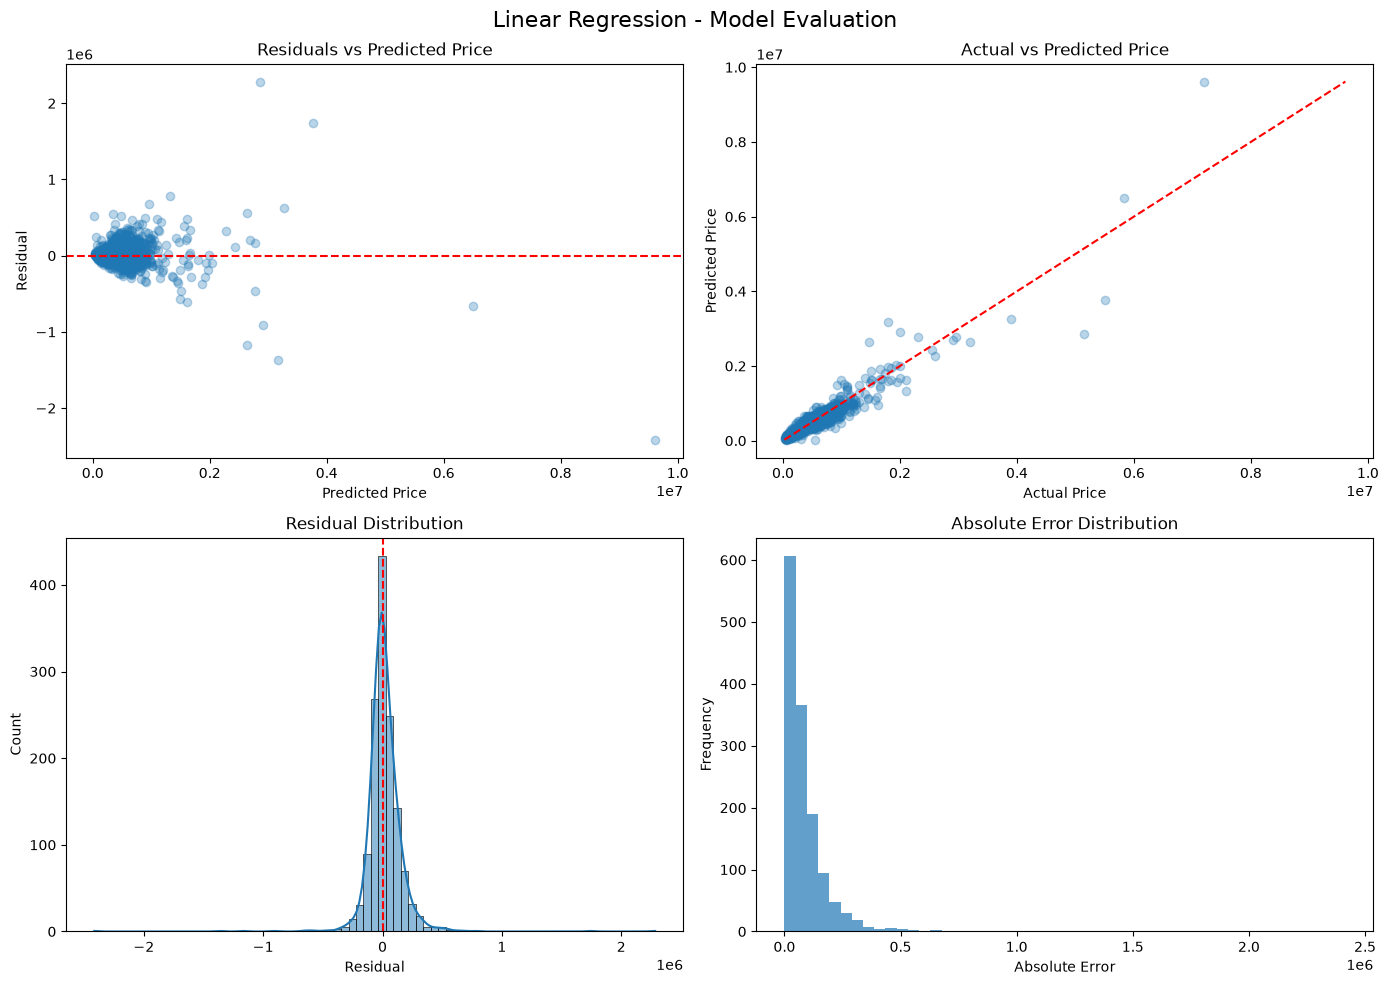


Ridge Regression
MAE:  91,944.22
RMSE: 171,262.35
R²:   0.8663

Residual statistics:
count    1.386000e+03
mean     1.691607e+04
std      1.704864e+05
min     -1.867740e+06
25%     -4.673774e+04
50%      1.081148e+03
75%      7.310179e+04
max      2.457354e+06
Name: selling_price, dtype: float64


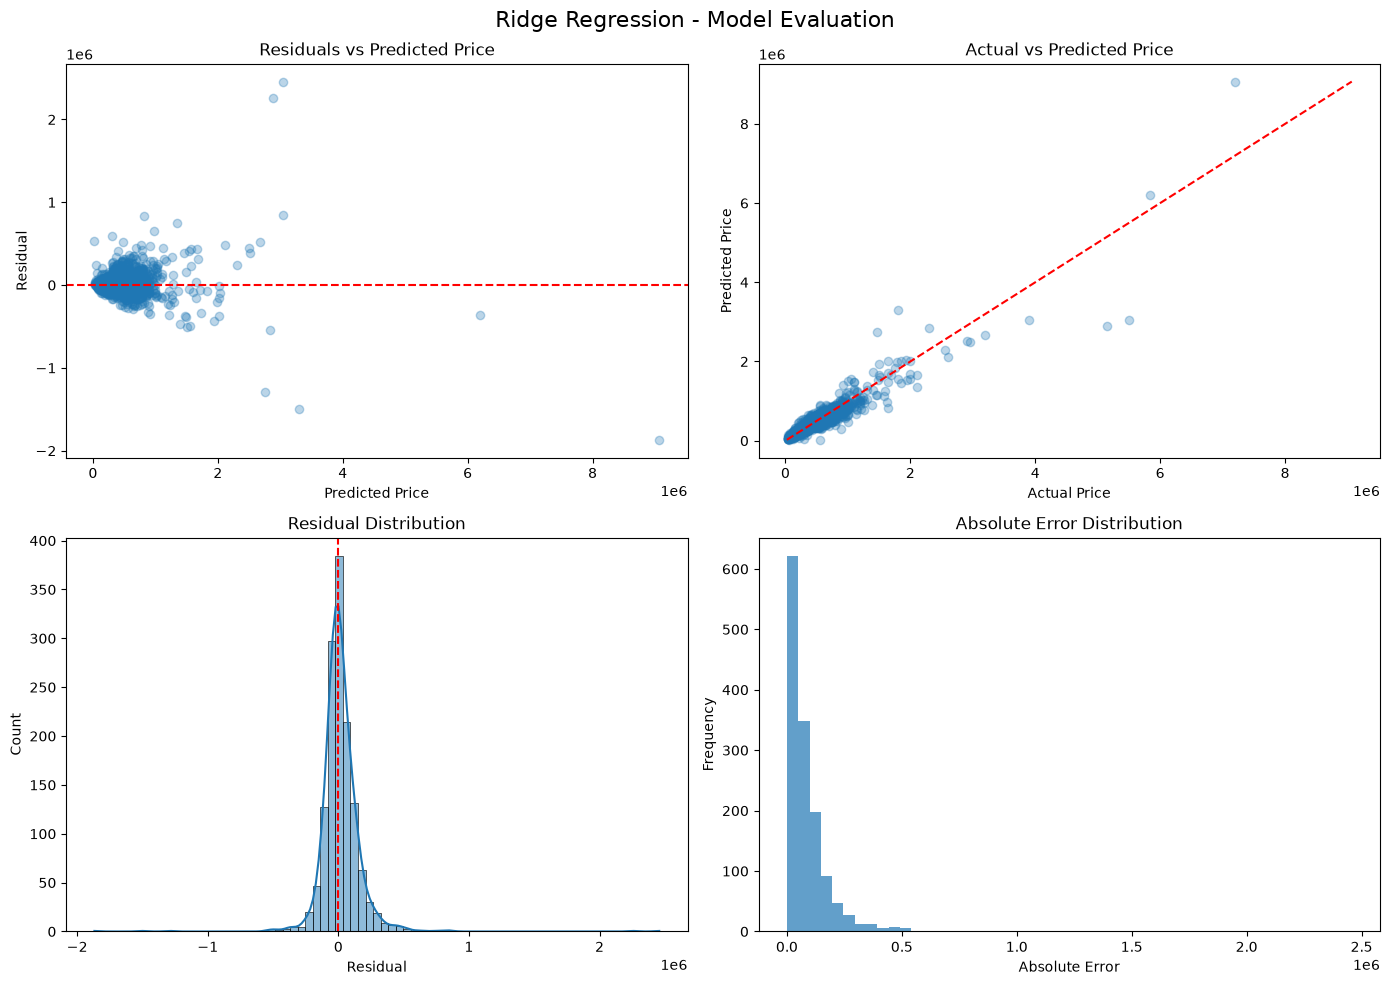


Lasso Regression
MAE:  93,540.24
RMSE: 175,863.33
R²:   0.8590

Residual statistics:
count    1.386000e+03
mean     1.798866e+04
std      1.750040e+05
min     -1.520463e+06
25%     -4.795742e+04
50%      1.734366e+03
75%      7.355541e+04
max      2.876056e+06
Name: selling_price, dtype: float64


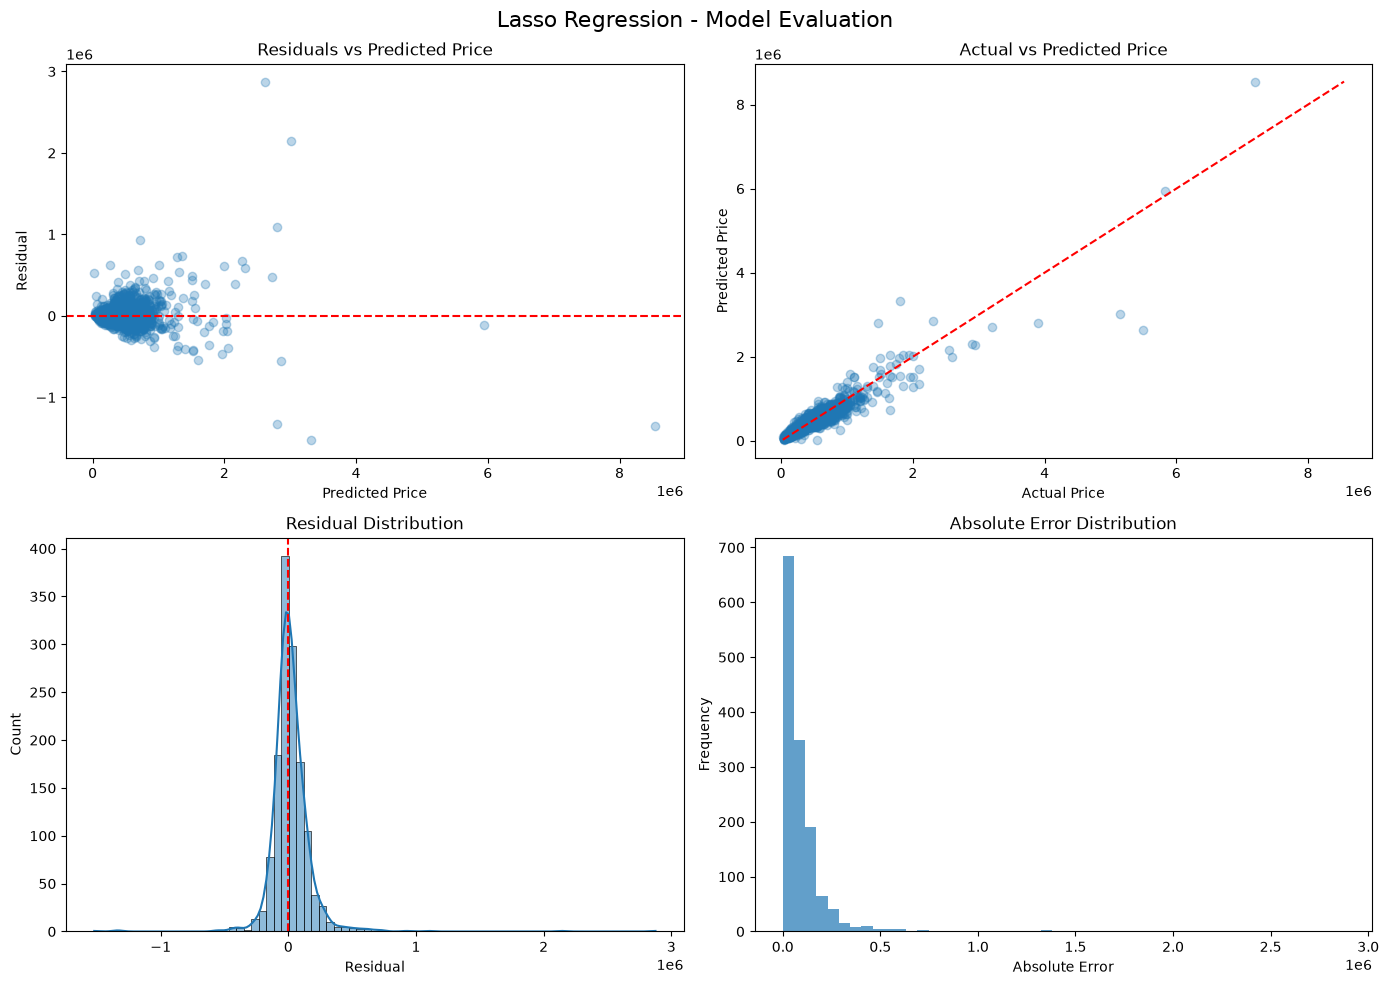


ElasticNet Regression
MAE:  92,792.76
RMSE: 176,312.30
R²:   0.8583

Residual statistics:
count    1.386000e+03
mean     1.724344e+04
std      1.755304e+05
min     -1.759436e+06
25%     -4.697426e+04
50%      1.399801e+03
75%      7.349664e+04
max      2.893625e+06
Name: selling_price, dtype: float64


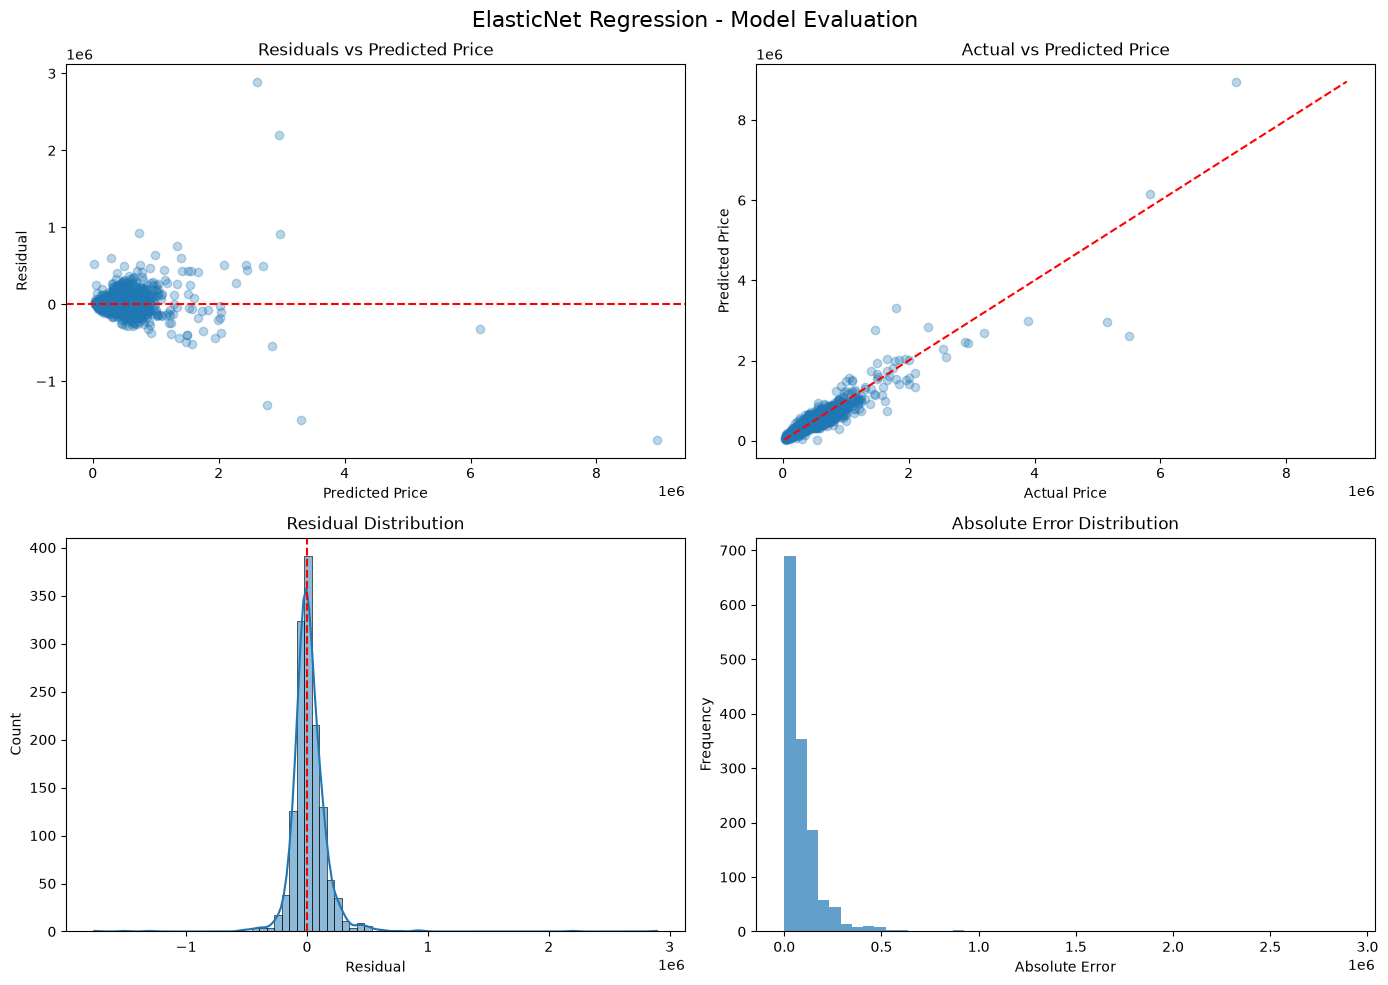


Random Forest
MAE:  70,561.01
RMSE: 119,660.63
R²:   0.9347

Residual statistics:
count    1.386000e+03
mean    -2.105355e+02
std      1.197036e+05
min     -9.735886e+05
25%     -4.853414e+04
50%     -5.014101e+03
75%      4.330035e+04
max      1.538276e+06
Name: selling_price, dtype: float64


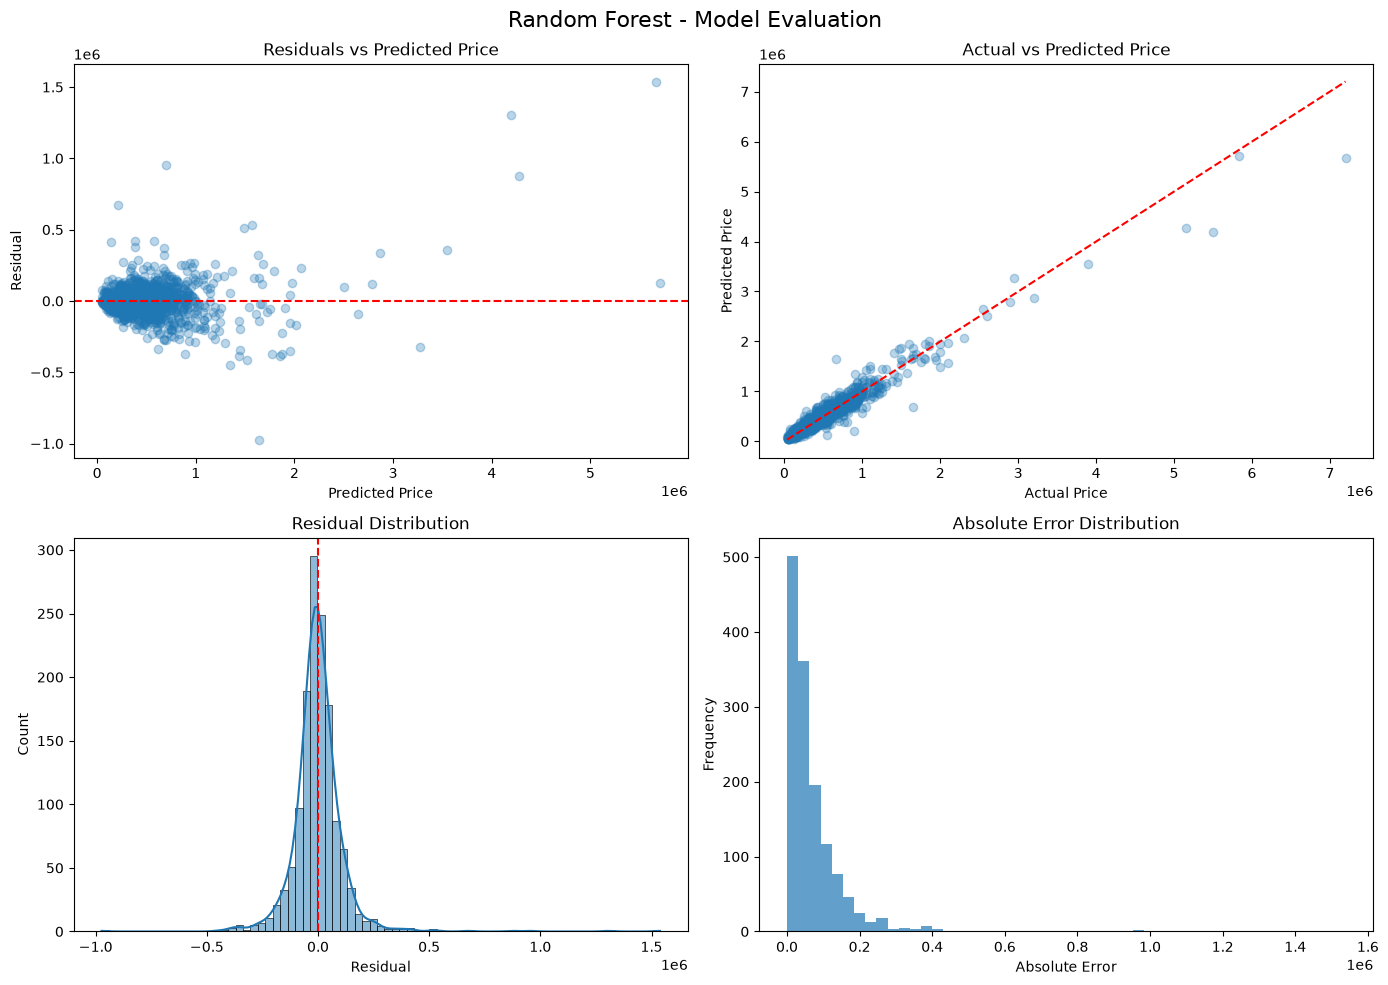


Gradient Boosting
MAE:  77,546.30
RMSE: 127,650.24
R²:   0.9257

Residual statistics:
count    1.386000e+03
mean    -3.971938e+02
std      1.276957e+05
min     -9.593615e+05
25%     -5.497575e+04
50%     -5.072088e+03
75%      4.784553e+04
max      1.565211e+06
Name: selling_price, dtype: float64


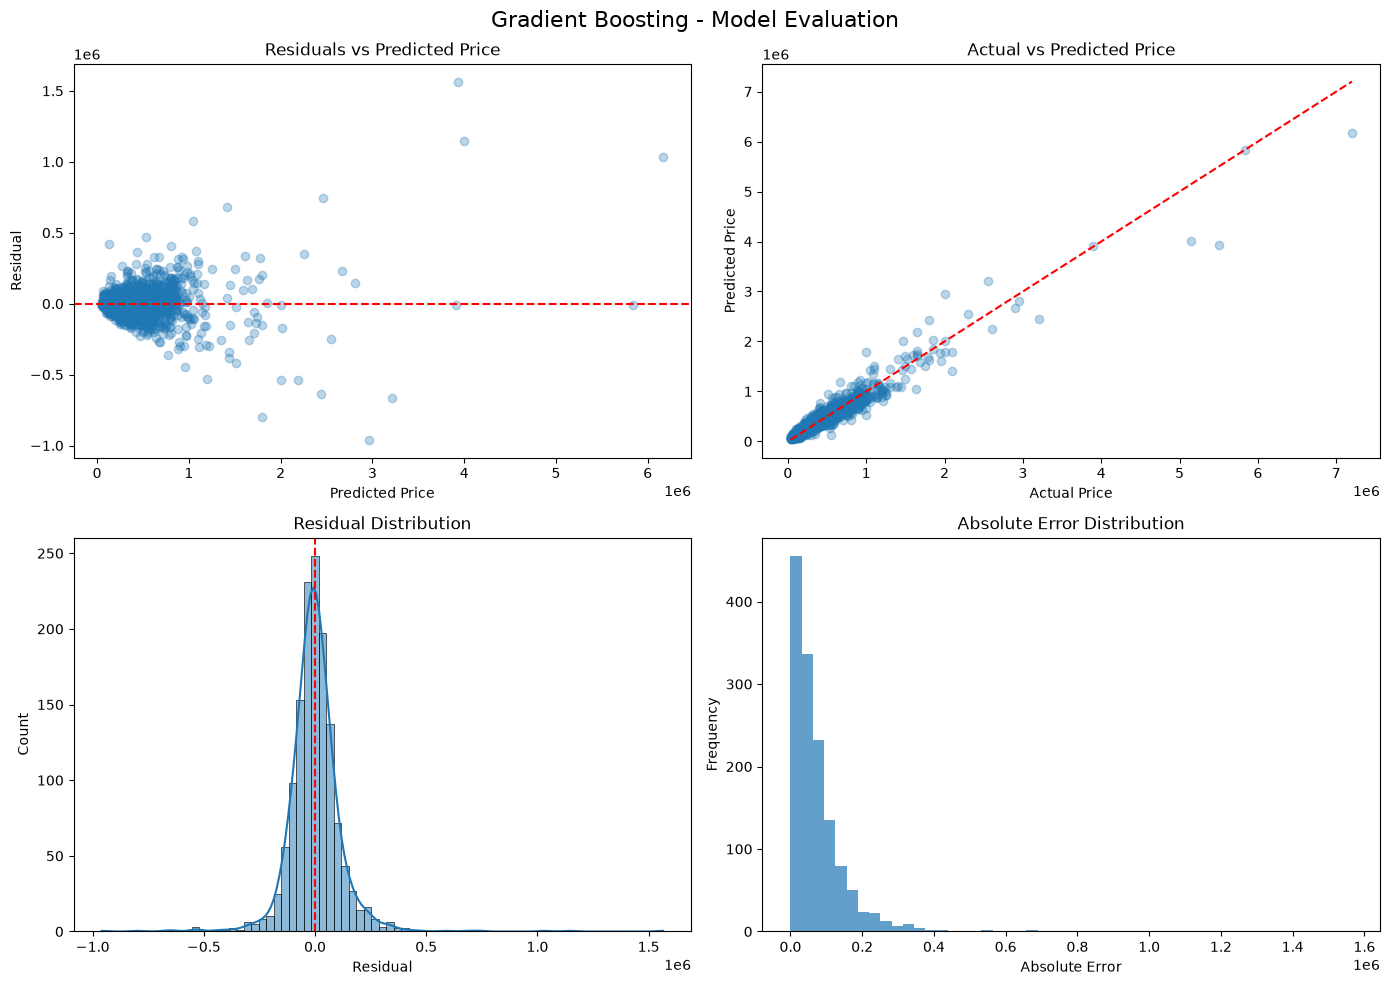

In [214]:
models = {
    "Linear Regression": baseline_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression":lasso_model,
    "ElasticNet Regression":elastic_model,
    'Random Forest':rf_model,
    "Gradient Boosting":gboosting_model,
    
}




def evaluate_model(model, X_test, y_test, model_name):
    
    # Predict
    y_pred_log = model.predict(X_test)
    
    # Convert predictions back to original price scale
    if model_name=='Random Forest' or model_name=='Gradient Boosting' :
        y_pred=y_pred_log
    else:
        y_pred = np.expm1(y_pred_log)
    
    # Residuals
    residuals = y_test - y_pred
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n{'=' * 50}")
    print(f"{model_name}")
    print(f"{'=' * 50}")
    print(f"MAE:  {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²:   {r2:.4f}")
    
    print("\nResidual statistics:")
    print(pd.Series(residuals).describe())
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Residuals vs predicted
    axes[0, 0].scatter(
        y_pred,
        residuals,
        alpha=0.3
    )
    axes[0, 0].axhline(
        0,
        color="red",
        linestyle="--"
    )
    axes[0, 0].set_xlabel("Predicted Price")
    axes[0, 0].set_ylabel("Residual")
    axes[0, 0].set_title("Residuals vs Predicted Price")
    
    # 2. Actual vs predicted
    axes[0, 1].scatter(
        y_test,
        y_pred,
        alpha=0.3
    )
    
    # Perfect prediction line
    min_value = min(y_test.min(), y_pred.min())
    max_value = max(y_test.max(), y_pred.max())
    
    axes[0, 1].plot(
        [min_value, max_value],
        [min_value, max_value],
        color="red",
        linestyle="--"
    )
    
    axes[0, 1].set_xlabel("Actual Price")
    axes[0, 1].set_ylabel("Predicted Price")
    axes[0, 1].set_title("Actual vs Predicted Price")
    
    # 3. Residual distribution
    sns.histplot(
        residuals,
        kde=True,
        ax=axes[1, 0]
    )
    axes[1, 0].axvline(
        0,
        color="red",
        linestyle="--"
    )
    axes[1, 0].set_xlabel("Residual")
    axes[1, 0].set_title("Residual Distribution")
    
    # 4. Absolute error
    absolute_errors = np.abs(residuals)
    
    axes[1, 1].hist(
        absolute_errors,
        bins=50,
        alpha=0.7
    )
    axes[1, 1].set_xlabel("Absolute Error")
    axes[1, 1].set_ylabel("Frequency")
    axes[1, 1].set_title("Absolute Error Distribution")
    
    plt.suptitle(
        f"{model_name} - Model Evaluation",
        fontsize=16
    )
    
    plt.tight_layout()
    plt.show()
    
    # Return everything so we can reuse it later
    return {
        "model": model_name,
        "predictions": y_pred,
        "residuals": residuals,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }
    
    
results = {}

for name, model in models.items():
    results[name] = evaluate_model(
        model,
        X_test,
        y_test,
        name
    )
    

In [215]:
tuned_pred=best_rf.predict(X_test)

In [216]:
error_df = X_test.copy()

error_df["actual_price"] = y_test.values
error_df["predicted_price"] = tuned_pred

error_df["error"] = (
    error_df["actual_price"]
    - error_df["predicted_price"]
)

error_df["absolute_error"] = (
    error_df["error"].abs()
)

error_df["percentage_error"] = (
    error_df["absolute_error"]
    / error_df["actual_price"]
) * 100

In [217]:
worst_predictions = (
    error_df
    .sort_values("absolute_error", ascending=False)
    .head(20)
)

In [218]:
worst_predictions[
    [
        "brand",
        "year",
        "km_driven",
        "fuel",
        "transmission",
        "owner",
        "actual_price",
        "predicted_price",
        "error",
        "percentage_error",
    ]
]

,brand,year,km_driven,fuel,transmission,owner,actual_price,predicted_price,error,percentage_error
2938,BMW,2020,5000,Diesel,Automatic,First Owner,7200000,5.661724e+06,1.538276e+06,21.364942
7930,Volvo,2019,17000,Diesel,Automatic,First Owner,5500000,4.194594e+06,1.305406e+06,23.734660
4592,Chevrolet,2013,65000,Diesel,Manual,First Owner,667000,1.640589e+06,-9.735886e+05,145.965303
2137,Land,2013,64788,Diesel,Automatic,First Owner,1650000,6.951695e+05,9.548305e+05,57.868514
132,Lexus,2019,20000,Petrol,Automatic,First Owner,5150000,4.277174e+06,8.728256e+05,16.948070
6598,BMW,2008,70000,Diesel,Automatic,Third Owner,890000,2.144978e+05,6.755022e+05,75.899121
4030,Toyota,2016,40000,Petrol,Automatic,First Owner,2100000,1.569228e+06,5.307721e+05,25.274861
6220,Honda,2019,24857,Petrol,Automatic,Test Drive Car,2000000,1.486732e+06,5.132676e+05,25.663378
4391,Volkswagen,2012,108000,Diesel,Automatic,First Owner,900000,1.350111e+06,-4.501113e+05,50.012371
5691,Nissan,2015,110000,Diesel,Manual,First Owner,1000000,5.779915e+05,4.220085e+05,42.200852


In [219]:
X_train[
    X_train["brand"] == "Land"
].head(20)

,year,km_driven,fuel,seller_type,transmission,owner,mileage,seats,engine_cc,max_power_bhp,torque_nm,torque_rpm_min,torque_rpm_max,brand,age
135,2019,21000,Diesel,Dealer,Automatic,First Owner,12.83,7.0,1999,148.31,382.0,1750.0,2250.0,Land,7
6724,2013,77500,Diesel,Individual,Automatic,Third Owner,12.7,5.0,2179,187.7,420.0,2000.0,2000.0,Land,13


In [220]:
error_df["price_range"] = pd.cut(
    error_df["actual_price"],
    bins=[
        0,
        200_000,
        500_000,
        1_000_000,
        2_000_000,
        float("inf"),
    ],
    labels=[
        "<200K",
        "200K-500K",
        "500K-1M",
        "1M-2M",
        ">2M",
    ],
)

In [221]:
error_by_range = (
    error_df
    .groupby("price_range", observed=True)
    .agg(
        MAE=("absolute_error", "mean"),
        RMSE=("error", lambda x: np.sqrt(np.mean(x**2))),
        Count=("error", "size"),
    )
)

error_by_range

,MAE,RMSE,Count
price_range,,,
<200K,38428.393105,51322.331087,276
200K-500K,53610.465925,72187.505543,595
500K-1M,84748.204461,124257.906802,435
1M-2M,184634.533880,235739.736910,67
>2M,465931.324841,655057.751476,13
